
# Childhood Stunting in India

**Akshit Chhabra | Akul Gupta | D A S K R Manognya | Saksham Chourasia**

**IIT Gandhinagar** &nbsp;·&nbsp; **CS 328 Writing Assignment**

Stunting (low height-for-age among children under 5) is one of the clearest markers of chronic nutritional deprivation. In India, stunting is not just a food problem: it sits at the intersection of sanitation, disease burden, maternal capability, and household living conditions.

This analysis studies childhood stunting in India at **two levels**:
1. **National context** using World Bank indicators over time.
2. **State-level variation** using NFHS-5 state factsheet data.

### Research question
Which state-level factors are most strongly associated with childhood stunting in India, and which states perform much better or worse than their overall development level would predict?

### Hypotheses
1. States with better sanitation tend to have lower stunting.
2. States with higher female literacy tend to have lower stunting.
3. States with higher household prosperity, using clean cooking fuel as a proxy for prosperity, tend to have lower stunting.
4. Some states remain unexplained even after accounting for these factors; identifying those anomalies is important.



In [1]:
# Install dependencies
!pip -q install statsmodels



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})



---
## Part 1: National Context

We use the following national indicators, which capture both nutritional outcomes and the disease pathway to stunting:

- **SH.STA.STNT.ZS**: prevalence of stunting among children under 5
- **SH.STA.ORTH**: children with diarrhoea receiving ORS packet / recommended fluids and continued feeding
- **SE.ADT.LITR.FE.ZS**: adult female literacy rate
- **SH.STA.BASS.ZS**: access to improved sanitation

This national section is used mainly for **context**, not for strong statistical inference, because the number of overlapping data points is small.


In [3]:
import glob

def load_wb_csv(filepath):
    df = pd.read_csv(filepath, skiprows=4)
    india = df[df['Country Code'] == 'IND'].iloc[0]
    years = [c for c in df.columns if c.isdigit()]
    series = india[years].rename(index=int)
    series = pd.to_numeric(series, errors='coerce')
    return series

stunting_raw   = load_wb_csv(glob.glob('API_SH.STA.STNT.ZS*.csv')[0])
ors_raw        = load_wb_csv(glob.glob('API_SH.STA.ORTH*.csv')[0])
sanitation_raw = load_wb_csv(glob.glob('API_SH.STA.BASS.ZS*.csv')[0])
literacy_raw   = load_wb_csv(glob.glob('API_SE.ADT.LITR.FE.ZS*.csv')[0])

national = pd.DataFrame({
    'stunting_rate':    stunting_raw,
    'ors_treatment':    ors_raw,
    'basic_sanitation': sanitation_raw,
    'female_literacy':  literacy_raw,
}).reset_index().rename(columns={'index': 'date'})

national = national.sort_values('date')

# interpolating with other indicators to match years where stunting data exists.
national_interp = national.set_index('date').interpolate(method='index').reset_index()
stunting_years = national.loc[national['stunting_rate'].notna(), 'date']
df_national = national_interp[national_interp['date'].isin(stunting_years)].copy()
df_national = df_national.rename(columns={'date': 'year'})

print(df_national[['year', 'stunting_rate', 'ors_treatment', 'basic_sanitation', 'female_literacy']].tail(10).to_string(index=False))


 year  stunting_rate  ors_treatment  basic_sanitation  female_literacy
 1989           62.7         13.000               NaN        32.120000
 1991           61.9         15.250               NaN        33.730000
 1992           57.1         16.375               NaN        35.141000
 1997           45.9         23.700               NaN        42.196000
 1999           51.0         26.800               NaN        45.018000
 2006           47.8         26.000         31.110275        50.820000
 2014           38.7         39.300         54.190551        61.699676
 2015           37.9         44.950         57.149639        62.580639
 2017           36.1         52.600         63.112558        64.342565
 2020           35.5         58.600         72.048233        67.573265


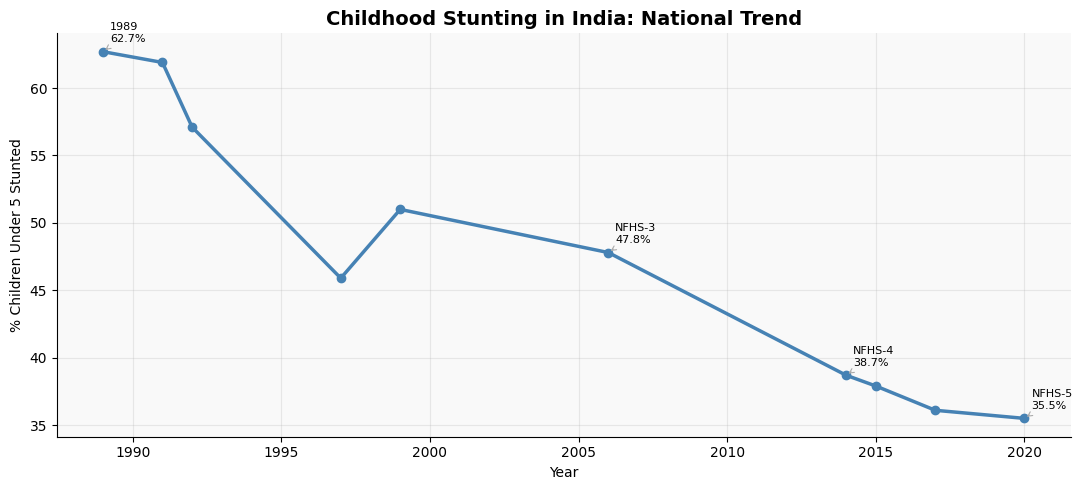

National decline: 62.7% → 35.5%  (27.2 percentage points)


In [4]:

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_national['year'], df_national['stunting_rate'],
        marker='o', color='steelblue', linewidth=2.5, markersize=6)

key_years = [(1989, '1989'), (2006, 'NFHS-3'), (2014, 'NFHS-4'), (2020, 'NFHS-5')]
for yr, label in key_years:
    row = df_national[df_national['year'] == yr]
    if not row.empty:
        val = float(row['stunting_rate'].iloc[0])
        ax.annotate(f'{label}\n{val:.1f}%', xy=(yr, val), xytext=(5, 7),
                    textcoords='offset points', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.set_title('Childhood Stunting in India: National Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Children Under 5 Stunted')
plt.tight_layout()
plt.show()

start = float(df_national['stunting_rate'].iloc[0])
end = float(df_national['stunting_rate'].iloc[-1])
print(f'National decline: {start:.1f}% → {end:.1f}%  ({start-end:.1f} percentage points)')



India has made substantial long-run progress in reducing childhood stunting, but the burden remains high. The national trend is useful as background, yet it cannot by itself explain **why some states do much better than others**. For that, we need state-level data.


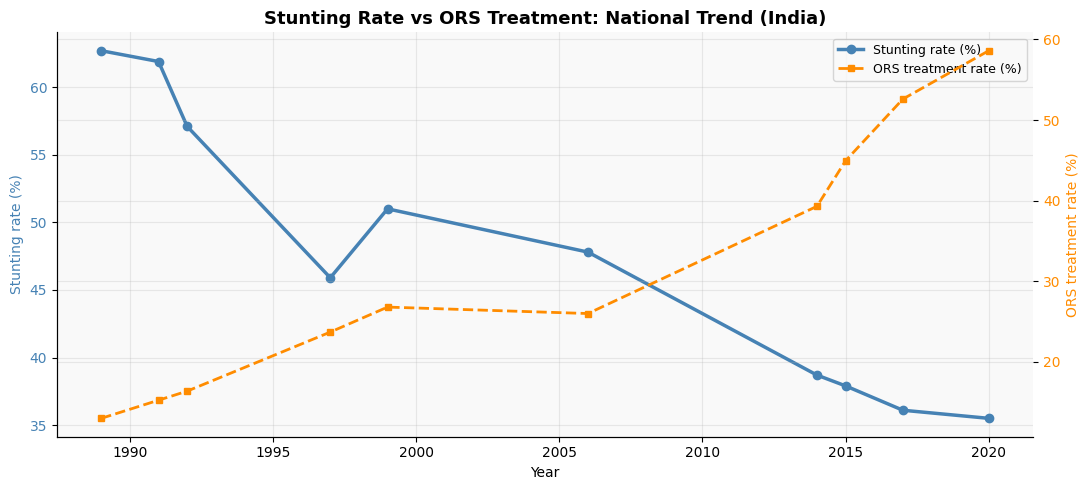

Pearson r (ORS vs stunting, n=4): r = -0.985, p = 0.0152


In [5]:
# ORS treatment rate vs stunting: national trend
fig, ax1 = plt.subplots(figsize=(11, 5))

color_stunt = 'steelblue'
color_ors   = 'darkorange'

ax1.plot(df_national['year'], df_national['stunting_rate'],
         marker='o', color=color_stunt, linewidth=2.5, markersize=6, label='Stunting rate (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Stunting rate (%)', color=color_stunt)
ax1.tick_params(axis='y', labelcolor=color_stunt)

ax2 = ax1.twinx()
ax2.plot(df_national['year'], df_national['ors_treatment'],
         marker='s', color=color_ors, linewidth=2, linestyle='--', markersize=5,
         label='ORS treatment rate (%)')
ax2.set_ylabel('ORS treatment rate (%)', color=color_ors)
ax2.tick_params(axis='y', labelcolor=color_ors)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.set_title('Stunting Rate vs ORS Treatment: National Trend (India)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pearson r over the overlapping years
ors_df = national.dropna(subset=['stunting_rate', 'ors_treatment'])
if len(ors_df) >= 3:
    r_ors, p_ors = stats.pearsonr(ors_df['ors_treatment'], ors_df['stunting_rate'])
    print(f"Pearson r (ORS vs stunting, n={len(ors_df)}): r = {r_ors:.3f}, p = {p_ors:.4f}")
else:
    print(f"Only {len(ors_df)} overlapping years, so the correlation is not reported; the chart is plotted for visual context only.")


### Disease pathway: ORS treatment as a proxy for diarrhoeal disease management

Childhood stunting is not driven by food deprivation alone. Repeated diarrhoeal illness (even mild episodes) impairs nutrient absorption and contributes to growth faltering. The World Bank indicator `SH.STA.ORTH` captures the share of children with diarrhoea who received oral rehydration solution (ORS), a direct marker of how well a country manages the leading child-disease pathway to stunting.

The dual-axis chart above places ORS treatment rates against the national stunting trend. Where ORS coverage rises, it should, all else equal, coincide with declining stunting, since better disease management reduces the nutrient-absorption losses from repeated illness. Because the national time series has only a handful of overlapping data points, this relationship is used as contextual evidence rather than as a primary statistical result; the state-level section below provides the more powerful state-level comparison. The trend alignment supports the broader narrative: India's stunting decline has been accompanied by gradual improvements across multiple child-health dimensions, not nutrition alone.



---
## Part 2: Loading the NFHS-5 State Data


In [6]:
# Load NFHS-5 state data
nfhs = pd.read_csv('nfhs5_state_data.csv')
print('Shape:', nfhs.shape)
print('Columns:', list(nfhs.columns[:10]))


Shape: (4819, 9)
Columns: ['S.No.', 'indicator code', 'Indicators', ' sub indicators', 'NFHS-5 (2019-20)', 'Unnamed: 5', 'Unnamed: 6', 'NFHS-4 2015-16', 'STATE/UT']


In [7]:
# Extract a single indicator from the NFHS dataframe by sub-indicator name.

def extract_indicator(df, sub_indicator, value_col='Unnamed: 6', indicator_group=None, state_col='STATE/UT'):
    work = df.copy()

    if indicator_group is not None:
        work = work[work['Indicators'] == indicator_group]

    work = work[work[' sub indicators'] == sub_indicator][[state_col, value_col]].copy()
    work.columns = ['state', 'value']
    work['value'] = pd.to_numeric(work['value'], errors='coerce')
    return work

# Stunting is extracted separately since we need both NFHS-4 and NFHS-5 columns.
stunting_state = nfhs[
    (nfhs['Indicators'] == 'Child Feeding Practices and Nutritional Status of Children') &
    (nfhs[' sub indicators'] == 'Children under 5 years who are stunted (height-for-age) (%)')
][['STATE/UT', 'NFHS-5 (2019-20)', 'Unnamed: 5', 'Unnamed: 6', 'NFHS-4 2015-16']].copy()

stunting_state.columns = ['state', 'urban', 'rural', 'nfhs5', 'nfhs4']
stunting_state['nfhs5'] = pd.to_numeric(stunting_state['nfhs5'], errors='coerce')
stunting_state['nfhs4'] = pd.to_numeric(stunting_state['nfhs4'], errors='coerce')
stunting_state = stunting_state.dropna(subset=['nfhs5'])

sanitation_state = extract_indicator(
    nfhs,
    'Population living in households that use an improved sanitation facility (%)'
).rename(columns={'value': 'sanitation'})

literacy_state = extract_indicator(
    nfhs,
    'Women who are literate (%)'
).rename(columns={'value': 'female_literacy'})

fuel_state = extract_indicator(
    nfhs,
    'Households using clean fuel for cooking (%)'
).rename(columns={'value': 'clean_fuel'})

df_state = (stunting_state
            .merge(sanitation_state, on='state', how='inner')
            .merge(literacy_state, on='state', how='inner')
            .merge(fuel_state, on='state', how='inner')
            .dropna())

df_state = df_state[['state', 'nfhs4', 'nfhs5', 'sanitation', 'female_literacy', 'clean_fuel']].copy()

print('Rows in analysis table:', len(df_state))
display(df_state.head())


Rows in analysis table: 37


,state,nfhs4,nfhs5,sanitation,female_literacy,clean_fuel
0,Andaman & Nicobar Islands,23.3,22.5,88.0,86.0,79.8
1,Andhra Pradesh,31.4,31.2,77.3,68.6,83.6
2,Assam,36.4,35.3,68.6,77.2,42.1
3,Bihar,48.3,42.9,49.4,57.8,37.8
4,Dadra & Nagar Haveli and Daman & Diu,37.2,39.4,65.8,77.3,79.9



---
## Part 3: State-Level Variation

The state-level table is the core analytical dataset. It allows us to compare both:
- **current stunting levels (NFHS-5)**
- **recent change since NFHS-4**

This lets us see where India is doing relatively well, and where it is not.


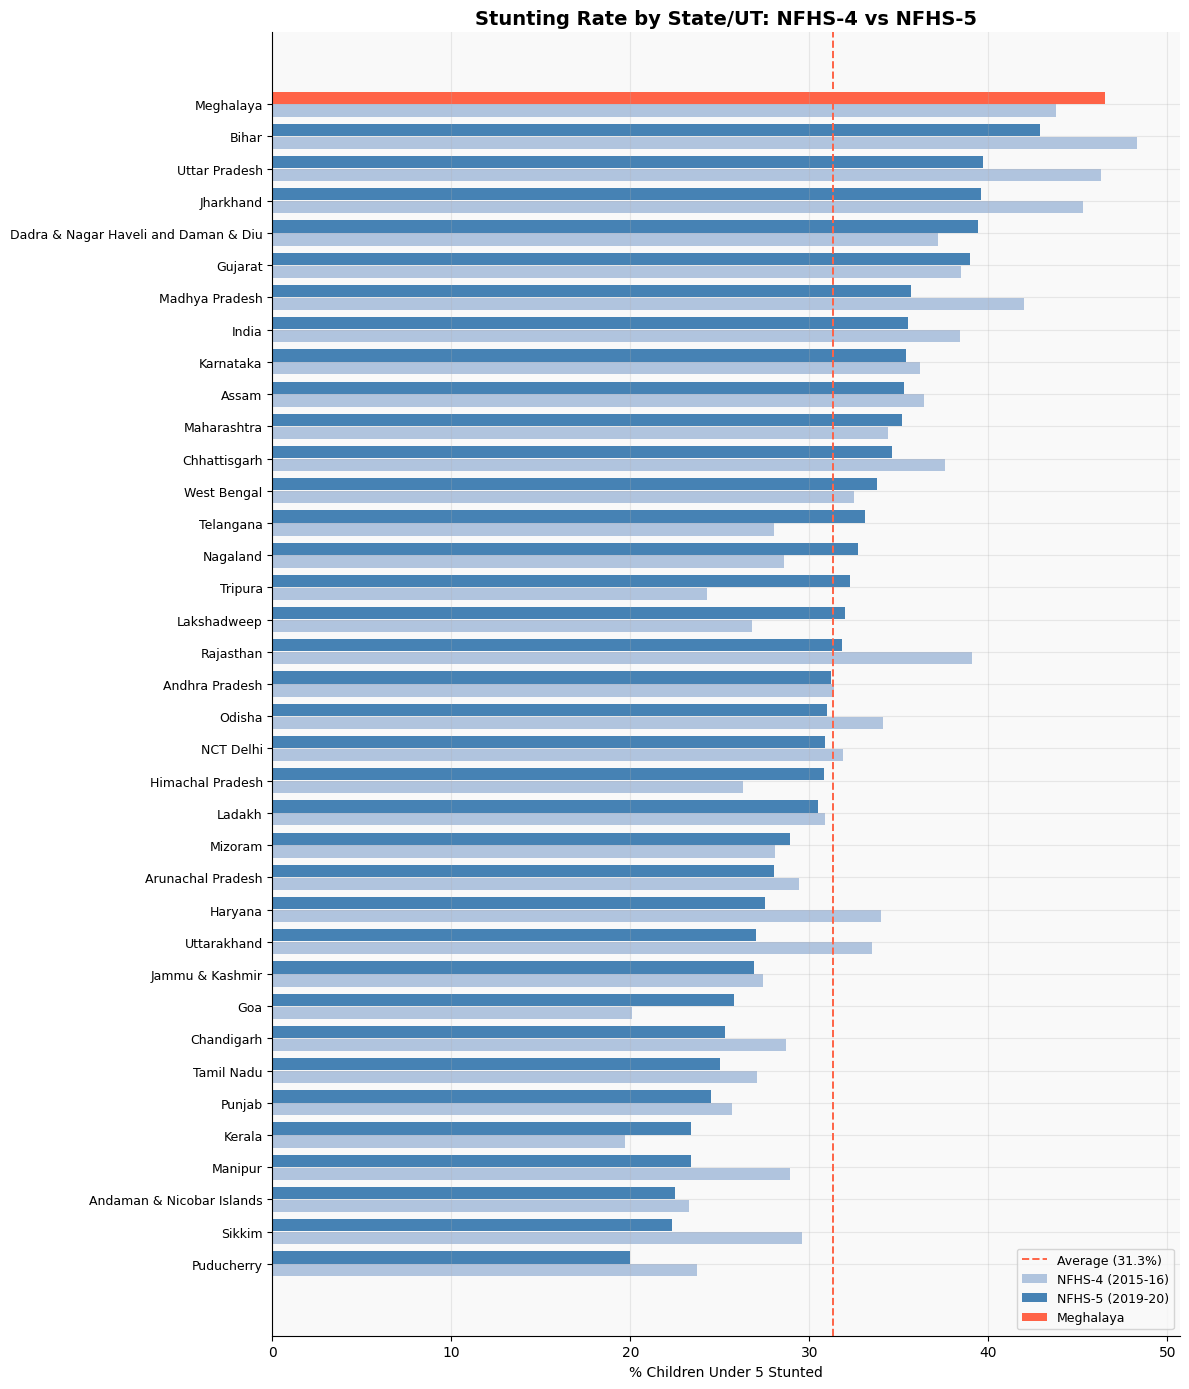

Best performer:  Puducherry : 20.0%
Worst performer: Meghalaya : 46.5%
Spread: 26.5 percentage points


In [8]:

df_bar = df_state.sort_values('nfhs5', ascending=True).reset_index(drop=True)
nat_avg = df_bar['nfhs5'].mean()

fig, ax = plt.subplots(figsize=(12, 14))
y = np.arange(len(df_bar))

ax.barh(y - 0.2, df_bar['nfhs4'], height=0.38, color='lightsteelblue', label='NFHS-4 (2015-16)')
ax.barh(y + 0.2, df_bar['nfhs5'], height=0.38, color='steelblue', label='NFHS-5 (2019-20)')

ax.set_yticks(y)
ax.set_yticklabels(df_bar['state'], fontsize=9)
ax.axvline(nat_avg, color='tomato', linestyle='--', linewidth=1.4, label=f'Average ({nat_avg:.1f}%)')

# Highlight Meghalaya if present.
meg_rows = df_bar.index[df_bar['state'].eq('Meghalaya')]
if len(meg_rows) > 0:
    meg_pos = int(meg_rows[0])
    ax.barh(meg_pos + 0.2, df_bar.loc[meg_pos, 'nfhs5'], height=0.38, color='tomato', label='Meghalaya')

ax.set_xlabel('% Children Under 5 Stunted')
ax.set_title('Stunting Rate by State/UT: NFHS-4 vs NFHS-5', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

best_state = df_bar.iloc[0]
worst_state = df_bar.iloc[-1]
spread = df_bar['nfhs5'].max() - df_bar['nfhs5'].min()

print(f"Best performer:  {best_state['state']} : {best_state['nfhs5']:.1f}%")
print(f"Worst performer: {worst_state['state']} : {worst_state['nfhs5']:.1f}%")
print(f"Spread: {spread:.1f} percentage points")


The cross-state spread is striking. The difference between the best and worst performing states exceeds 25 percentage points, meaning a child born in the lowest-burden state/UT faces roughly one-quarter the stunting risk of a child born in the highest-burden state. This is a larger gap than the one between India and the global average, which underscores that the national average is a poor summary of any individual child's risk.

The side-by-side NFHS-4 and NFHS-5 bars also reveal heterogeneity in the direction of change. Several high-burden states show meaningful reductions; a smaller number show increases. This variation is important: it rules out the simple explanation that "all states are just converging slowly" and raises the question of what separates improvers from non-improvers, a question addressed in the temporal analysis in Part 7.

Three broad tiers are visible: a low-burden tier (mostly southern and north-eastern states/UTs, stunting below ~26%), a mid-burden tier (23–35%, the majority of states), and a high-burden tier dominated by the large north Indian states where stunting exceeds 35%. Policy efforts that treat all states identically are unlikely to be efficient given this structure.



---
## Part 4: Bivariate Hypothesis Tests

We begin with simple Pearson correlations. These are easy to interpret and visually intuitive.

Important caution: these are **associations**, not causal estimates.


In [9]:

def scatter_with_regression(ax, x_col, y_col, df, xlabel, ylabel, title, color='steelblue', highlight='Meghalaya'):
    x = df[x_col]
    y = df[y_col]
    slope, intercept, r, p, _ = stats.linregress(x, y)

    colors_pt = ['tomato' if s == highlight else color for s in df['state']]
    ax.scatter(x, y, c=colors_pt, s=70, zorder=5, edgecolors='white', linewidth=0.5)

    label_states = ['Meghalaya', 'Bihar', 'Kerala', 'Sikkim', 'Uttar Pradesh', 'Manipur', 'Goa']
    for _, row in df[df['state'].isin(label_states)].iterrows():
        ax.annotate(row['state'], (row[x_col], row[y_col]), textcoords='offset points',
                    xytext=(5, 4), fontsize=7.5, color='#333')

    lx = np.linspace(x.min(), x.max(), 200)
    ax.plot(lx, slope * lx + intercept, color='#555', linewidth=2, linestyle='--')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nr = {r:.2f}, p = {p:.4f}', fontsize=11)
    return r, p


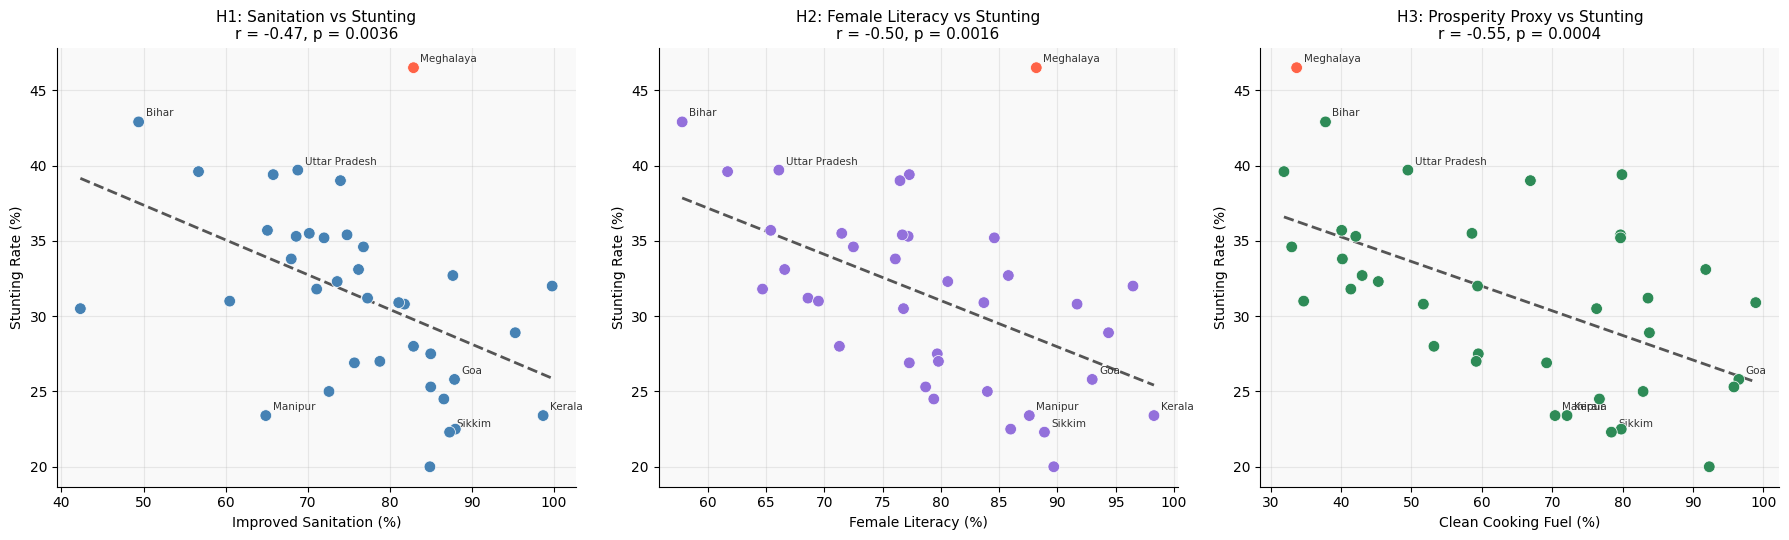

,Predictor,r,p_value
0,Sanitation,-0.4661,0.0036
1,Female literacy,-0.5018,0.0016
2,Clean fuel (prosperity proxy),-0.5516,0.0004


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

r1, p1 = scatter_with_regression(
    axes[0], 'sanitation', 'nfhs5', df_state,
    xlabel='Improved Sanitation (%)',
    ylabel='Stunting Rate (%)',
    title='H1: Sanitation vs Stunting',
    color='steelblue'
)

r2, p2 = scatter_with_regression(
    axes[1], 'female_literacy', 'nfhs5', df_state,
    xlabel='Female Literacy (%)',
    ylabel='Stunting Rate (%)',
    title='H2: Female Literacy vs Stunting',
    color='mediumpurple'
)

r3, p3 = scatter_with_regression(
    axes[2], 'clean_fuel', 'nfhs5', df_state,
    xlabel='Clean Cooking Fuel (%)',
    ylabel='Stunting Rate (%)',
    title='H3: Prosperity Proxy vs Stunting',
    color='seagreen'
)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Predictor': ['Sanitation', 'Female literacy', 'Clean fuel (prosperity proxy)'],
    'r': [r1, r2, r3],
    'p_value': [p1, p2, p3]
})
display(summary.round(4))


The bivariate results confirm all three hypotheses in the expected direction: sanitation, female literacy, and clean cooking fuel are each negatively associated with childhood stunting, meaning states where these indicators are higher tend to have lower stunting rates. The correlations are statistically significant (p < 0.05 in each case) and the magnitudes are meaningful.

Among the three, **clean fuel use** (the prosperity proxy) typically shows the strongest bivariate correlation. This is not surprising: wealth is a "bundled" variable that captures many advantages simultaneously (better diet diversity, access to healthcare, lower disease exposure, more educated mothers). This does not mean prosperity is the most actionable lever; it may simply be the most correlated because it indexes so many underlying factors at once.

**Female literacy** shows a strong and important association. States with higher female literacy consistently have lower stunting, which aligns with a large international literature showing that a mother's education is one of the most robust predictors of child nutritional status, independent of household income.

**Sanitation** is the variable most directly connected to the disease pathway: better toilet access reduces faecal-oral contamination, cuts diarrhoeal incidence, and which protects the absorptive capacity of the gut. Its correlation with stunting is consistent with the national ORS-treatment evidence shown in Part 1.

However, these predictors are themselves correlated; richer states also tend to have better sanitation and more educated women. The next section therefore moves beyond bivariate analysis to ask which predictors retain explanatory power when they compete with one another.



---
## Part 5: Multivariable Model

A multiple regression does not solve causality, but it does answer a sharper descriptive question:

> Holding the other two predictors constant, which variables still retain explanatory power?

To compare effect sizes fairly, We standardize the predictors before fitting the model.


In [11]:

model_df = df_state[['state', 'nfhs5', 'sanitation', 'female_literacy', 'clean_fuel']].copy()

X = model_df[['sanitation', 'female_literacy', 'clean_fuel']]
y = model_df['nfhs5']

X_std = (X - X.mean()) / X.std(ddof=0)
y_std = (y - y.mean()) / y.std(ddof=0)

X_std_const = sm.add_constant(X_std)
ols_std = sm.OLS(y_std, X_std_const).fit()

coef_table = pd.DataFrame({
    'Predictor': ['Sanitation', 'Female literacy', 'Clean fuel'],
    'Std_beta': ols_std.params.drop('const').values,
    'p_value': ols_std.pvalues.drop('const').values
}).sort_values('Std_beta')

display(coef_table.round(4))
print(ols_std.summary())


,Predictor,Std_beta,p_value
2,Clean fuel,-0.4017,0.0105
1,Female literacy,-0.2065,0.2968
0,Sanitation,-0.1802,0.3467


                            OLS Regression Results                            
Dep. Variable:                  nfhs5   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     7.619
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           0.000528
Time:                        12:00:07   Log-Likelihood:                -42.764
No. Observations:                  37   AIC:                             93.53
Df Residuals:                      33   BIC:                             99.97
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.527e-16      0.134  -1.

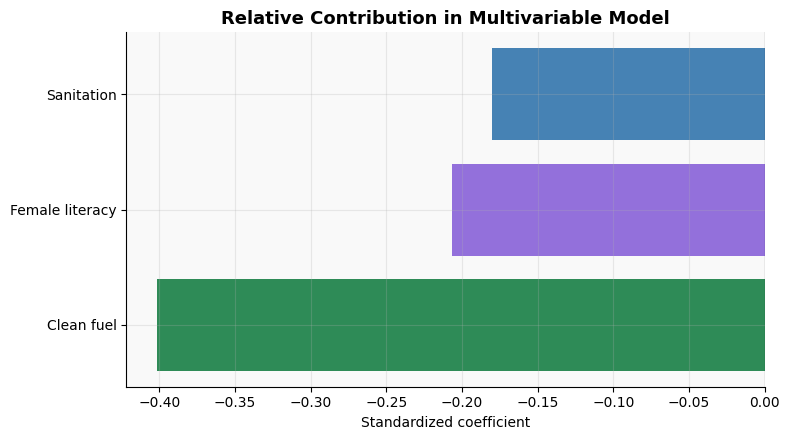

In [12]:

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = coef_table.sort_values('Std_beta')
color_map = {'Sanitation': 'steelblue', 'Female literacy': 'mediumpurple', 'Clean fuel': 'seagreen'}
colors = [color_map[p] for p in plot_df['Predictor']]
ax.barh(plot_df['Predictor'], plot_df['Std_beta'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized coefficient')
ax.set_title('Relative Contribution in Multivariable Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


This multivariable step goes further than the bivariate tests: it asks whether each predictor retains explanatory power when the others are held constant.

The results show that only **clean fuel** retains statistical significance in the full model (p = 0.01). Sanitation (p = 0.35) and female literacy (p = 0.30) both lose significance once they compete with clean fuel. This might seem to contradict H1 and H2, but it does not — it reflects **multicollinearity**. Our three predictors are not independent: wealthier states tend to have better sanitation and more educated women at the same time. When all three enter the model together, it becomes difficult to separate their individual contributions, and clean fuel (as the strongest prosperity proxy) absorbs most of the explanatory power.

This does not mean sanitation and literacy are unimportant. It means our three predictors are largely measuring overlapping aspects of the same underlying phenomenon: overall state development level. The bivariate results (Part 4) remain valid as descriptions of each variable's association with stunting in isolation.



---
## Part 6: Robustness Check : What Happens Without Meghalaya?

Because Meghalaya appears visually unusual, We check whether the broad pattern survives when that single observation is removed. If the results collapse completely, the story is fragile. If they broadly persist, the story is much stronger.


In [13]:

def corr_stats(df, x, y='nfhs5'):
    r, p = stats.pearsonr(df[x], df[y])
    return r, p

rows = []
for label, subset in [('All states/UTs', df_state), ('Excluding Meghalaya', df_state[df_state['state'] != 'Meghalaya'])]:
    for var in ['sanitation', 'female_literacy', 'clean_fuel']:
        r, p = corr_stats(subset, var)
        rows.append({'Sample': label, 'Predictor': var, 'r': r, 'p_value': p})

robustness = pd.DataFrame(rows)
display(robustness.round(4))


,Sample,Predictor,r,p_value
0,All states/UTs,sanitation,-0.4661,0.0036
1,All states/UTs,female_literacy,-0.5018,0.0016
2,All states/UTs,clean_fuel,-0.5516,0.0004
3,Excluding Meghalaya,sanitation,-0.5562,0.0004
4,Excluding Meghalaya,female_literacy,-0.6290,0.0000
5,Excluding Meghalaya,clean_fuel,-0.5096,0.0015



---
## Part 7: Residual Analysis - Who Overperforms and Underperforms?

Beyond asking which predictors matter, We also ask which places are not well explained by them. This highlights states that perform unexpectedly well or poorly.


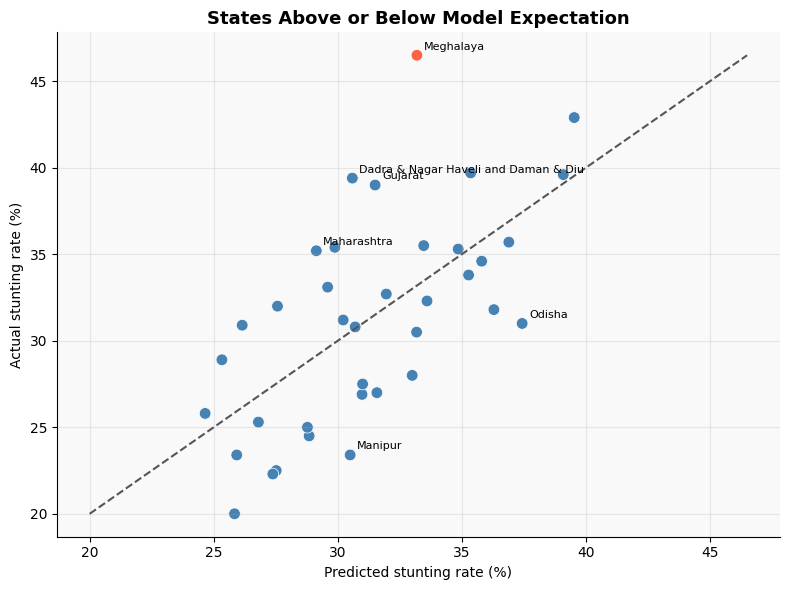

,state,nfhs5,predicted_nfhs5,residual
14,Meghalaya,46.5,33.19,13.31
4,Dadra & Nagar Haveli and Daman & Diu,39.4,30.59,8.81
6,Gujarat,39.0,31.51,7.49
15,Manipur,23.4,30.50,-7.10
28,Odisha,31.0,37.43,-6.43
13,Maharashtra,35.2,29.14,6.06
36,Puducherry,20.0,25.84,-5.84
9,Karnataka,35.4,29.88,5.52
18,Sikkim,22.3,27.38,-5.08
0,Andaman & Nicobar Islands,22.5,27.52,-5.02


In [14]:

X_raw = sm.add_constant(model_df[['sanitation', 'female_literacy', 'clean_fuel']])
ols_raw = sm.OLS(model_df['nfhs5'], X_raw).fit()

model_df['predicted_nfhs5'] = ols_raw.predict(X_raw)
model_df['residual'] = model_df['nfhs5'] - model_df['predicted_nfhs5']
model_df['abs_residual'] = model_df['residual'].abs()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if s == 'Meghalaya' else 'steelblue' for s in model_df['state']]
ax.scatter(model_df['predicted_nfhs5'], model_df['nfhs5'], c=colors, s=70, edgecolors='white', linewidth=0.5)

line_min = min(model_df['predicted_nfhs5'].min(), model_df['nfhs5'].min())
line_max = max(model_df['predicted_nfhs5'].max(), model_df['nfhs5'].max())
ax.plot([line_min, line_max], [line_min, line_max], linestyle='--', color='#555')

for _, row in model_df.nlargest(6, 'abs_residual').iterrows():
    ax.annotate(row['state'], (row['predicted_nfhs5'], row['nfhs5']),
                textcoords='offset points', xytext=(5, 4), fontsize=8)

ax.set_xlabel('Predicted stunting rate (%)')
ax.set_ylabel('Actual stunting rate (%)')
ax.set_title('States Above or Below Model Expectation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(model_df.sort_values('abs_residual', ascending=False)[['state', 'nfhs5', 'predicted_nfhs5', 'residual']].head(10).round(2))


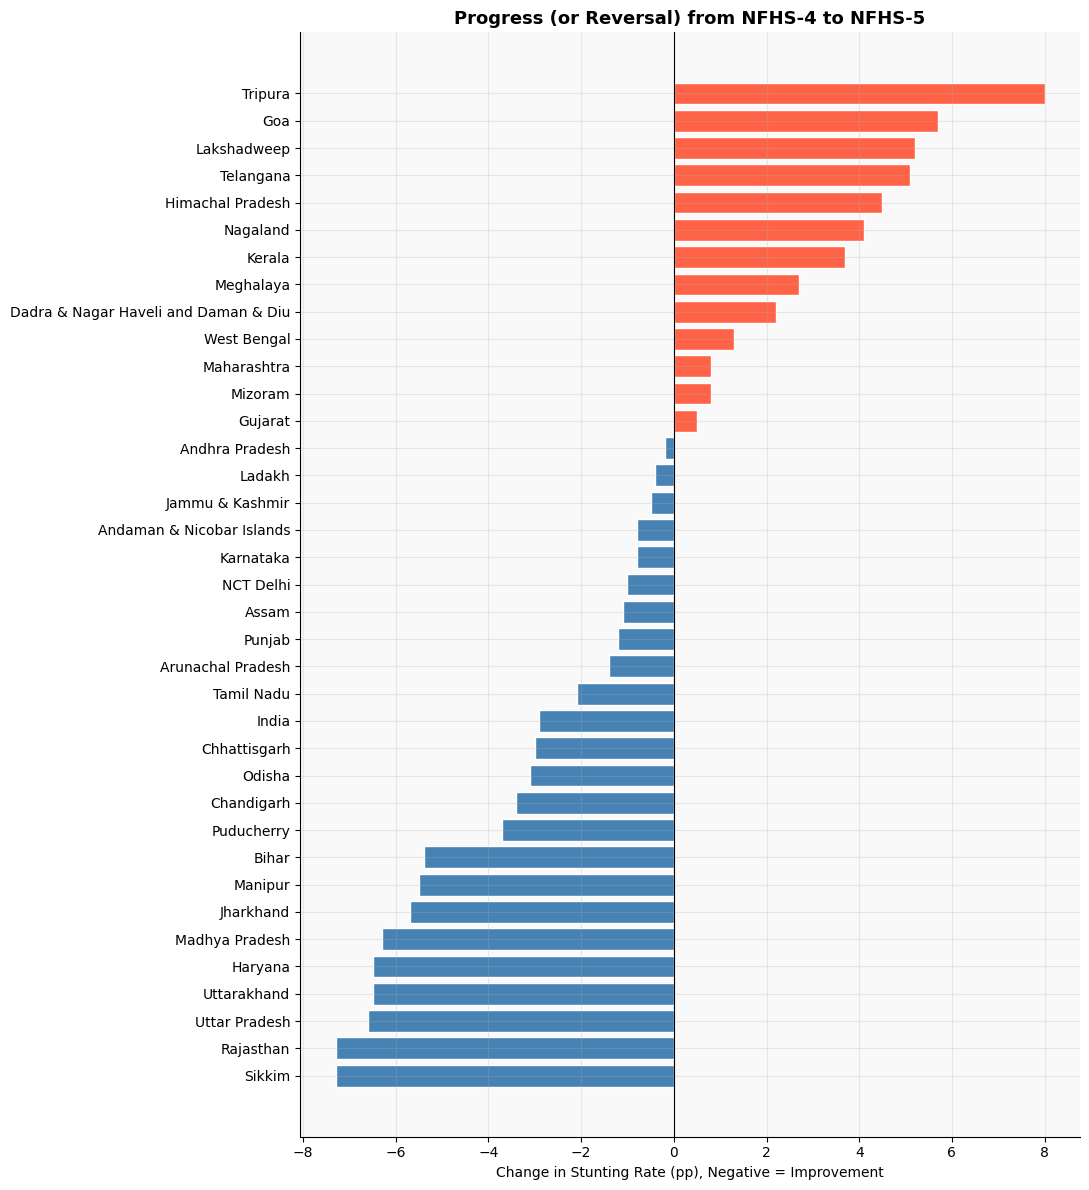

24 states/UTs improved, 13 worsened
Biggest improver: Sikkim (-7.3 pp)
Biggest worsening: Tripura (+8.0 pp)


In [15]:

# NFHS-4 to NFHS-5 change analysis
change_df = df_state.copy()
change_df['change'] = change_df['nfhs5'] - change_df['nfhs4']  # negative = improvement
change_df = change_df.sort_values('change')

fig, ax = plt.subplots(figsize=(11, 12))
colors = ['tomato' if v > 0 else 'steelblue' for v in change_df['change']]
ax.barh(change_df['state'], change_df['change'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in Stunting Rate (pp), Negative = Improvement')
ax.set_title('Progress (or Reversal) from NFHS-4 to NFHS-5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

improved = int((change_df['change'] < 0).sum())
worsened = int((change_df['change'] > 0).sum())
print(f'{improved} states/UTs improved, {worsened} worsened')
print(f"Biggest improver: {change_df.iloc[0]['state']} ({change_df.iloc[0]['change']:.1f} pp)")
print(f"Biggest worsening: {change_df.iloc[-1]['state']} (+{change_df.iloc[-1]['change']:.1f} pp)")


### Interpreting the NFHS-4 to NFHS-5 trajectory

The bar chart above separates two distinct questions that are often conflated: which states have the highest burden today, and which states are actually making progress? These are not the same question, and conflating them leads to misleading policy conclusions.

Most states and Union Territories showed improvement between NFHS-4 (2015–16) and NFHS-5 (2019–21), reflecting that India's nationwide stunting decline documented in Part 1 was broadly distributed across regions. The largest improvers tend to cluster among states that had both high initial burden and greater scope for catching up, consistent with a catch-up pattern where the worst-performing regions improve fastest once basic interventions (safe water, improved sanitation, Anganwadi coverage) reach sufficient scale.

The states that worsened between rounds are a more important policy signal. A rising stunting rate during a period when national investment in nutrition programmes (POSHAN Abhiyaan was launched in 2018) was increasing suggests that local implementation capacity, or localised shocks such as drought, displacement, or COVID-related disruption to ICDS services, may have offset national-level progress. Meghalaya, already flagged as an outlier in the residual analysis, also shows limited improvement on this temporal dimension, reinforcing its status as a state whose stunting burden is not well explained by the standard predictors.

Combined with the regression in Part 5, this temporal picture completes the argument: India's problem is not uniform; it is concentrated in a small number of high-burden, slow-improving states where the underlying factors (sanitation, literacy, prosperity) remain relatively weak.



---
## Findings

Key findings:

1. **All three headline variables are negatively associated with stunting in bivariate analysis.**
2. **Prosperity (proxied by clean fuel use) is often the strongest single bivariate correlate**, but this should be interpreted as association, not proof of causation.
3. **A multivariable model is more demanding**: once the predictors compete with one another, some coefficients may weaken because sanitation, education, and prosperity tend to move together.
4. **Outlier analysis matters.** A state like Meghalaya is interesting precisely because it is not well explained by the standard predictors.
5. **Change over time matters too.** A state can have a high burden today yet still be improving fast, or vice versa.

That last point is important: it separates “high burden” from “policy stagnation”.



---
## Limitations

We are clear about what this analysis can and cannot claim.

- The analysis is based on **state-level aggregates**, so it cannot identify household-level causal mechanisms.
- Correlation and regression here are **descriptive**, not causal.
- Clean fuel is used as a **proxy** for prosperity; it is useful, but imperfect.
- The national disease indicator (ORS treatment) is informative for context, but not directly merged into the state-level model.
- A stronger extension would incorporate additional child-health variables such as diarrhoeal burden, wasting, anaemia, low birth weight, or breastfeeding indicators where comparable data are available.

Being explicit about these limits makes the conclusions more credible.



---
## Conclusion

India has reduced childhood stunting substantially over the long run, but the burden remains unevenly distributed across states and UTs. The state-level analysis shows that better sanitation, higher female literacy, and greater household prosperity are all associated with lower stunting. Among the three, prosperity often appears as the strongest **single bivariate correlate**, though the multivariable model is the more appropriate summary once overlap across predictors is taken into account.

Beyond restating known associations, the analysis shows that **some states do not behave as the simple model predicts**. That is where policy attention should go next: not only toward states with high stunting, but toward states whose outcomes remain surprisingly poor even after accounting for sanitation, literacy, and prosperity.

In that sense, the main conclusion is clear: childhood stunting in India is best understood not as an isolated nutrition statistic, but as a broader marker of uneven development.
